# Import and explore the data

In [10]:
import pandas as pd
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split

raw_train = pd.read_csv('../data/train.csv', index_col="ID")
raw_clientes = pd.read_csv('../data/clientes.csv', index_col="customer_id")

raw_data = pd.merge(raw_train, raw_clientes, how='left', on='customer_id')


In [11]:
print(f"{raw_train.shape[0]:,} rows x {raw_train.shape[1]} feature columns, indexed by RecordID")

6,534 rows x 38 feature columns, indexed by RecordID


In [12]:
print(f"{raw_data.shape[0]:,} rows x {raw_data.shape[1]} feature columns, indexed by RecordID")

6,534 rows x 50 feature columns, indexed by RecordID


### Check missing values

In [27]:
raw_data.isna().sum()

Total a Pagar                        0
Total Bruto                          0
Total Liquido                        0
Total Imp_                           0
Total Portes                         0
Total Desc_ Global                   0
Total Desc_ Linha                    0
Custo                                0
N_ Detalhes                          0
invoice_count_current_purchase       0
days_since_previous_purchase       796
customer_tenure_days                 0
prior_purchase_count                 0
prior_total_spend                    0
prior_mean_purchase_value          797
prior_std_purchase_value          1048
prior_min_purchase_value           603
prior_max_purchase_value           603
prior_mean_gap_days               1243
prior_std_gap_days                1413
purchase_count_30d                   0
spend_30d                            0
purchase_count_90d                   0
spend_90d                            0
purchase_count_180d                  0
spend_180d               

In [13]:
target = raw_train["repeat_purchase_90d"]
raw_train.drop(columns=["repeat_purchase_90d"], inplace=True)
raw_data.drop(columns=["repeat_purchase_90d"], inplace=True)

In [28]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
#raw_data[raw_data.isna().any(axis=1)]
raw_data[raw_data["Total a Pagar"].isna()].T


""
Total a Pagar
Total Bruto
Total Liquido
Total Imp_
Total Portes
Total Desc_ Global
Total Desc_ Linha
Custo
N_ Detalhes
invoice_count_current_purchase


In [15]:
raw_data.drop(columns=["customer_type"], inplace=True)

In [8]:
(raw_data.isna().sum() == 65).sum()

np.int64(24)

In [17]:
raw_data.dropna(subset=["Total a Pagar"], inplace=True)

In [18]:
raw_data.drop_duplicates(inplace=True)

In [43]:
na_summary = pd.DataFrame({
    "NA_count": raw_data.isna().sum(),
    "NA_percentage": raw_data.isna().mean() * 100
})

print(na_summary.sort_values("NA_count", ascending=False))

                                NA_count  NA_percentage
street                              3808      58.865358
island                              2189      33.838306
city                                2128      32.895347
prior_std_gap_days                  1413      21.842634
prior_mean_gap_days                 1243      19.214716
prior_std_purchase_value            1048      16.200340
prior_mean_purchase_value            797      12.320297
days_since_previous_purchase         796      12.304838
prior_max_purchase_value             603       9.321379
prior_min_purchase_value             603       9.321379
postal_area                          278       4.297418
postal_code                          223       3.447210
municipality                         217       3.354460
transport_method                     196       3.029835
warehouse                            195       3.014376
spend_365d                           195       3.014376
payment_type                         195       3

<Axes: title={'center': 'Missing Values by Feature'}, ylabel='Missing values (%)'>

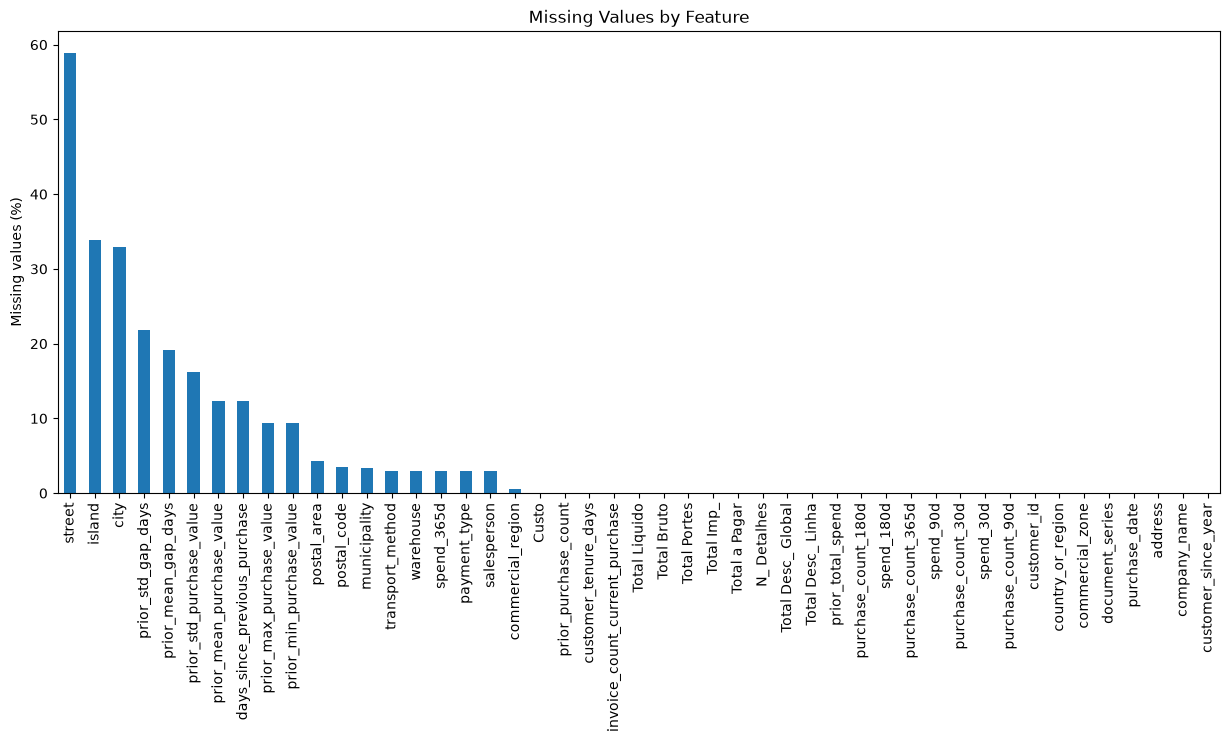

In [44]:
na_percentage = raw_data.isna().mean() * 100

na_percentage = na_percentage.sort_values(ascending=False)

na_percentage.plot(
    kind="bar",
    figsize=(15, 6),
    ylabel="Missing values (%)",
    title="Missing Values by Feature"
)

### Assertions

In [32]:
raw_data

,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,days_since_previous_purchase,customer_tenure_days,prior_purchase_count,prior_total_spend,prior_mean_purchase_value,prior_std_purchase_value,prior_min_purchase_value,prior_max_purchase_value,prior_mean_gap_days,prior_std_gap_days,purchase_count_30d,spend_30d,purchase_count_90d,spend_90d,purchase_count_180d,spend_180d,purchase_count_365d,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,country_or_region,commercial_region,island,municipality,city,postal_area,postal_code,street,address,company_name,customer_since_year
0,558.11,510.90,453.75,104.36,0.0,0.00,57.15,153.099911,4.0,1.0,79.0,126.0,2.0,858.30,429.150000,112.656252,349.49,508.81,47.000000,NaN,0.0,0.00,1.0,349.49,2.0,858.30,2.0,858.30,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,Country CT10: Land of The Final Version,Region RG25: We Will See Later,NaN,Municipality MU89: Council of Last Minute Edits,City CY286: Cached Result Falls,Postal area PA228: Hidden Sheet Sector,Postal code PC444: #REF! Delivery Route,Street ST303: Absolute Reference Terrace,Address AD761: Cell Without a Home,Excel Is Not A Database Ltd 1013,2024
1,978.80,830.02,795.77,183.03,0.0,0.00,34.25,472.943134,32.0,1.0,244.0,616.0,5.0,6722.83,1344.566000,1683.795178,84.38,4222.15,93.000000,117.657696,0.0,0.00,0.0,0.00,0.0,0.00,4.0,2500.68,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS8: The Pivot Archipelago,Municipality MU11: Council of Last Minute Edits,City CY147: VLOOKUP Bay,Postal area PA260: Hidden Sheet Sector,Postal code PC636: #REF! Delivery Route,NaN,Address AD382: Cell Without a Home,Excel Is Not A Database Ltd 35,2015
2,10.33,12.00,8.40,1.93,0.0,0.00,3.60,6.097485,1.0,1.0,9.0,610.0,90.0,17590.08,195.445333,190.389932,4.54,1002.15,6.752809,6.384073,2.0,111.27,9.0,1928.55,28.0,5290.25,49.0,7899.80,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,Country CT10: Land of The Final Version,Region RG23: We Will See Later,NaN,Municipality MU70: Council of Last Minute Edits,City CY265: Where-less Query Falls,Postal area PA84: Hidden Sheet Sector,Postal code PC200: #REF! Delivery Route,NaN,Address AD723: Cell Without a Home,Excel Is Not A Database Ltd 826,2017
3,856.83,696.61,696.61,160.22,0.0,0.00,0.00,408.167275,9.0,1.0,97.0,97.0,1.0,270.33,270.330000,NaN,270.33,270.33,NaN,NaN,0.0,0.00,0.0,0.00,1.0,270.33,1.0,270.33,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS7: The Pivot Archipelago,Municipality MU12: Council of Last Minute Edits,NaN,Postal area PA253: Hidden Sheet Sector,Postal code PC558: #REF! Delivery Route,Street ST144: Last Save Court,Address AD399: Cell Without a Home,Excel Is Not A Database Ltd 530,2018
4,1616.10,1488.85,1313.90,302.20,0.0,0.00,174.95,485.401864,33.0,1.0,85.0,1575.0,25.0,12803.02,512.120800,406.696963,22.58,1736.74,62.083333,66.246520,0.0,0.00,2.0,184.13,4.0,2062.50,4.0,2062.50,122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,Country CT10: Land of The Final Version,Region RG31: We Will See Later,NaN,Municipality MU142: Council of Last Minute Edits,City CY359: Spill Error Ridge,Postal area PA136: Hidden Sheet Sector,Postal code PC300: #REF! Delivery Route,Street ST395: AutoFill Path,Address AD928: Cell With

In [8]:
raw_data.dropna(inplace=True)

In [25]:
raw_data.dtypes

Total a Pagar                            float64
Total Bruto                              float64
Total Liquido                            float64
Total Imp_                               float64
Total Portes                             float64
Total Desc_ Global                       float64
Total Desc_ Linha                        float64
Custo                                    float64
N_ Detalhes                              float64
invoice_count_current_purchase           float64
days_since_previous_purchase             float64
customer_tenure_days                     float64
prior_purchase_count                     float64
prior_total_spend                        float64
prior_mean_purchase_value                float64
prior_std_purchase_value                 float64
prior_min_purchase_value                 float64
prior_max_purchase_value                 float64
prior_mean_gap_days                      float64
prior_std_gap_days                       float64
purchase_count_30d  

In [21]:
float_features = raw_data.select_dtypes(include=['float64']).columns
string_features = raw_data.select_dtypes(include=['str']).columns
int_features = raw_data.select_dtypes(include=['int64']).columns

In [22]:
negative_counts = (raw_data[float_features] < 0).sum()

# Keep only features that contain negative values
negative_features = negative_counts[negative_counts > 0]

# Rows containing at least one negative value
negative_rows = (raw_data[float_features] < 0).any(axis=1)



print("\nFeatures with negative values:")
print(negative_features.sort_values(ascending=False))
print(f"Number of rows with negative values: {negative_rows.sum()}")


Features with negative values:
days_since_previous_purchase    16
prior_mean_purchase_value       16
prior_mean_gap_days             16
spend_365d                      15
dtype: int64
Number of rows with negative values: 63


In [73]:
raw_data.drop(raw_data[negative_rows].index, inplace=True)

In [23]:
for col in string_features:
    print(f"\n{col}:")
    print(raw_data[col].unique())


payment_type:
<StringArray>
['Maybe Tomorrow Payment 10',  'Maybe Tomorrow Payment 7',
  'Maybe Tomorrow Payment 9', 'Maybe Tomorrow Payment 12',
                         nan,  'Maybe Tomorrow Payment 2',
  'Maybe Tomorrow Payment 8',  'Maybe Tomorrow Payment 3',
  'Maybe Tomorrow Payment 4', 'Maybe Tomorrow Payment 11']
Length: 10, dtype: str

salesperson:
<StringArray>
['VLOOKUP Master 9', 'VLOOKUP Master 1', 'VLOOKUP Master 4',
                nan, 'VLOOKUP Master 2', 'VLOOKUP Master 7',
 'VLOOKUP Master 6', 'VLOOKUP Master 3', 'VLOOKUP Master 5',
 'VLOOKUP Master 8']
Length: 10, dtype: str

commercial_zone:
<StringArray>
['Decorative Dashboard Zone 4', 'Decorative Dashboard Zone 2',
 'Decorative Dashboard Zone 3', 'Decorative Dashboard Zone 6',
 'Decorative Dashboard Zone 7']
Length: 5, dtype: str

transport_method:
<StringArray>
['Maybe Tomorrow Delivery 61', 'Maybe Tomorrow Delivery 36',
                          nan, 'Maybe Tomorrow Delivery 71',
 'Maybe Tomorrow Delivery 62', 

In [24]:
raw_data["purchase_date"] = pd.to_datetime(raw_data["purchase_date"])

In [13]:
raw_data[string_features]

,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,country_or_region,commercial_region,island,municipality,city,postal_area,postal_code,street,address,company_name
0,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,Country CT10: Land of The Final Version,Region RG25: We Will See Later,NaN,Municipality MU89: Council of Last Minute Edits,City CY286: Cached Result Falls,Postal area PA228: Hidden Sheet Sector,Postal code PC444: #REF! Delivery Route,Street ST303: Absolute Reference Terrace,Address AD761: Cell Without a Home,Excel Is Not A Database Ltd 1013
1,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS8: The Pivot Archipelago,Municipality MU11: Council of Last Minute Edits,City CY147: VLOOKUP Bay,Postal area PA260: Hidden Sheet Sector,Postal code PC636: #REF! Delivery Route,NaN,Address AD382: Cell Without a Home,Excel Is Not A Database Ltd 35
2,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,Country CT10: Land of The Final Version,Region RG23: We Will See Later,NaN,Municipality MU70: Council of Last Minute Edits,City CY265: Where-less Query Falls,Postal area PA84: Hidden Sheet Sector,Postal code PC200: #REF! Delivery Route,NaN,Address AD723: Cell Without a Home,Excel Is Not A Database Ltd 826
3,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS7: The Pivot Archipelago,Municipality MU12: Council of Last Minute Edits,NaN,Postal area PA253: Hidden Sheet Sector,Postal code PC558: #REF! Delivery Route,Street ST144: Last Save Court,Address AD399: Cell Without a Home,Excel Is Not A Database Ltd 530
4,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,Country CT10: Land of The Final Version,Region RG31: We Will See Later,NaN,Municipality MU142: Council of Last Minute Edits,City CY359: Spill Error Ridge,Postal area PA136: Hidden Sheet Sector,Postal code PC300: #REF! Delivery Route,Street ST395: AutoFill Path,Address AD928: Cell Without a Home,Excel Is Not A Database Ltd 220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6529,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 72,Final Excel Warehouse 1,Ctrl Z Series 3,2016-01-24,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS4: The Pivot Archipelago,Municipality MU15: Council of Last Minute Edits,City CY172: Pivot Table Grove,Postal area PA267: Hidden Sheet Sector,Postal code PC785: #REF! Delivery Route,NaN,Address AD472: Cell Without a Home,Excel Is Not A Database Ltd 967
6530,Maybe Tomorrow Payment 12,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 1,2021-04-13,Country CT10: Land of The Final Version,Region RG18: We Will See Later,NaN,Municipality MU32: Council of Last Minute Edits,NaN,Postal area PA142: Hidden Sheet Sector,Postal code PC309: #REF! Delivery Route,NaN,Address AD615: Cell Without a Home,Excel Is Not A Database Ltd 191
6531,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 72,Final Excel Warehouse 1,Ctrl Z Series 2,2022-03-19,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS4: The Pivot Archipelago,Municipality MU15: Council of Last Minute Edits,City CY180: Frozen Pane Grove,Postal area PA267: Hidden Sheet Sector,Postal code PC778: #REF! Delivery Route,Street ST171: VLOOKUP Walk,Addr

In [26]:
raw_data

,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,days_since_previous_purchase,customer_tenure_days,prior_purchase_count,prior_total_spend,prior_mean_purchase_value,prior_std_purchase_value,prior_min_purchase_value,prior_max_purchase_value,prior_mean_gap_days,prior_std_gap_days,purchase_count_30d,spend_30d,purchase_count_90d,spend_90d,purchase_count_180d,spend_180d,purchase_count_365d,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,country_or_region,commercial_region,island,municipality,city,postal_area,postal_code,street,address,company_name,customer_since_year
0,558.11,510.90,453.75,104.36,0.0,0.00,57.15,153.099911,4.0,1.0,79.0,126.0,2.0,858.30,429.150000,112.656252,349.49,508.81,47.000000,NaN,0.0,0.00,1.0,349.49,2.0,858.30,2.0,858.30,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,Country CT10: Land of The Final Version,Region RG25: We Will See Later,NaN,Municipality MU89: Council of Last Minute Edits,City CY286: Cached Result Falls,Postal area PA228: Hidden Sheet Sector,Postal code PC444: #REF! Delivery Route,Street ST303: Absolute Reference Terrace,Address AD761: Cell Without a Home,Excel Is Not A Database Ltd 1013,2024
1,978.80,830.02,795.77,183.03,0.0,0.00,34.25,472.943134,32.0,1.0,244.0,616.0,5.0,6722.83,1344.566000,1683.795178,84.38,4222.15,93.000000,117.657696,0.0,0.00,0.0,0.00,0.0,0.00,4.0,2500.68,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS8: The Pivot Archipelago,Municipality MU11: Council of Last Minute Edits,City CY147: VLOOKUP Bay,Postal area PA260: Hidden Sheet Sector,Postal code PC636: #REF! Delivery Route,NaN,Address AD382: Cell Without a Home,Excel Is Not A Database Ltd 35,2015
2,10.33,12.00,8.40,1.93,0.0,0.00,3.60,6.097485,1.0,1.0,9.0,610.0,90.0,17590.08,195.445333,190.389932,4.54,1002.15,6.752809,6.384073,2.0,111.27,9.0,1928.55,28.0,5290.25,49.0,7899.80,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,Country CT10: Land of The Final Version,Region RG23: We Will See Later,NaN,Municipality MU70: Council of Last Minute Edits,City CY265: Where-less Query Falls,Postal area PA84: Hidden Sheet Sector,Postal code PC200: #REF! Delivery Route,NaN,Address AD723: Cell Without a Home,Excel Is Not A Database Ltd 826,2017
3,856.83,696.61,696.61,160.22,0.0,0.00,0.00,408.167275,9.0,1.0,97.0,97.0,1.0,270.33,270.330000,NaN,270.33,270.33,NaN,NaN,0.0,0.00,0.0,0.00,1.0,270.33,1.0,270.33,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS7: The Pivot Archipelago,Municipality MU12: Council of Last Minute Edits,NaN,Postal area PA253: Hidden Sheet Sector,Postal code PC558: #REF! Delivery Route,Street ST144: Last Save Court,Address AD399: Cell Without a Home,Excel Is Not A Database Ltd 530,2018
4,1616.10,1488.85,1313.90,302.20,0.0,0.00,174.95,485.401864,33.0,1.0,85.0,1575.0,25.0,12803.02,512.120800,406.696963,22.58,1736.74,62.083333,66.246520,0.0,0.00,2.0,184.13,4.0,2062.50,4.0,2062.50,122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,Country CT10: Land of The Final Version,Region RG31: We Will See Later,NaN,Municipality MU142: Council of Last Minute Edits,City CY359: Spill Error Ridge,Postal area PA136: Hidden Sheet Sector,Postal code PC300: #REF! Delivery Route,Street ST395: AutoFill Path,Address AD928: Cell With

In [41]:
def check_positive_floats(df, columns):
    for col in columns:
        assert df[col].notna().all(), f"{col} contains NA"
        assert df[col].dtype == "float64", f"{col} is not float"
        assert (df[col] >= 0).all(), f"{col} contains non-positive values"

def check_positive_ints(df, columns):
    for col in columns:
        assert df[col].notna().all(), f"{col} contains NA"
        assert df[col].dtype == "int64", f"{col} is not int"
        assert (df[col] >= 0).all(), f"{col} contains non-positive values"

assert ((raw_data["customer_since_year"] >= 1950) & (raw_data["customer_since_year"] <= 2026)).all(), f"{col} contains non-positive values"

def check_non_empty_strings(df, columns):
    for col in columns:
        assert df[col].notna().all(), f"{col} contains NA"
        assert df[col].str.strip().ne("").all(), f"{col} contains empty strings"

In [42]:
check_positive_floats(raw_data, float_features)
check_positive_ints(raw_data, int_features)
check_non_empty_strings(raw_data, string_features)

AssertionError: days_since_previous_purchase contains NA

In [ ]:
#verify all float features are positive
raw_data[negative_rows]

,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,days_since_previous_purchase,customer_tenure_days,prior_purchase_count,prior_total_spend,prior_mean_purchase_value,prior_std_purchase_value,prior_min_purchase_value,prior_max_purchase_value,prior_mean_gap_days,prior_std_gap_days,purchase_count_30d,spend_30d,purchase_count_90d,spend_90d,purchase_count_180d,spend_180d,purchase_count_365d,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,country_or_region,commercial_region,island,municipality,city,postal_area,postal_code,street,address,company_name,customer_since_year


In [31]:
raw_data.duplicated().sum()

np.int64(10)

In [ ]:
raw_train

In [ ]:
print(raw_train.head())
print("\ninfo of the training data:")
print(raw_train.info())
print("\ndescriptive statistics of the training data:")
print(raw_train.describe())
print("\nna values in each column:n")
print(raw_train.isna().sum())

In [ ]:
print(raw_clientes.head())
print("\ninfo of the training data:")
print(raw_clientes.info())
print("\ndescriptive statistics of the training data:")
print(raw_clientes.describe())
print("\nna values in each column:n")
print(raw_clientes.isna().sum())

In [25]:
raw_train[["repeat_purchase_90d", "random_noise"]].corr()

,repeat_purchase_90d,random_noise
repeat_purchase_90d,1.000000,-0.011988
random_noise,-0.011988,1.000000


In [31]:
raw_train["random_noise"] = raw_train["random_noise"].fillna(raw_train["random_noise"].mean())

In [34]:
F, p = f_classif(raw_train[[ "random_noise" ]], raw_train["repeat_purchase_90d"])

print(F)
print(p)

[0.92936305]
[0.33506418]


In [20]:
raw_train.groupby("repeat_purchase_90d")["random_noise"].describe()

,count,mean,std,min,25%,50%,75%,max
repeat_purchase_90d,,,,,,,,
0,2848.0,-0.008609,0.996088,-3.529210,-0.642745,-0.043238,0.635513,4.151241
1,3621.0,-0.032783,1.004952,-3.263267,-0.715974,-0.047517,0.649046,3.435928


In [19]:
raw_data.drop(columns=["random_noise"], inplace=True)

In [ ]:
raw_data["repeat_purchase_90d"].value_counts(normalize=True)

repeat_purchase_90d
1    0.559229
0    0.440771
Name: proportion, dtype: float64

In [ ]:
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")


To gain an initial understanding of the data structure, data types, and quality, we performed a exploratory analysis using typicall methods such as head(), info(), describe(), and null-value checking that we learned in class. Here´s what we discover: 

Training Dataset (train.csv) 

- **Dimensions**: Comprises 6,534 purchase occasions (Observations/rows) and 39 variables (Columns).  
- **Target Variable**: The target variable "repeat_purchase_90d" contains 0 missing values, as we can see in info(), which is good. 
- **Missing Values and Anomalies**: 
  - Financial columns (e.g., "Total a Pagar", "Custo") exhibit exactly **65 missing values** (6534 - 6469), indicating rows with incomplete data.
  - Historical temporal columns (such as "days_since_previous_purchase" and "prior_mean_gap_days") show a higher number of nulls.
    
Customer Dataset (clientes.csv) 

- **Dimensions**: Contains **1,143 unique customer profiles** mapped through "customer_id".
- This Dataset also has some missing values including a column with no data


# Clean and pre-process the data

In [52]:

# 1. Fazer o merge com a tabela de clientes (excluindo a coluna 100% vazia 'customer_type')
clientes_clean = raw_clientes.drop(columns=['customer_type'])
train_merged = raw_train.merge(clientes_clean, on='customer_id', how='left')

# 2. Tratar valores em falta nas colunas numéricas (preenchendo com 0)
numeric_cols = train_merged.select_dtypes(include=['float64', 'int64']).columns
train_merged[numeric_cols] = train_merged[numeric_cols].fillna(0)

# 3. Tratar valores em falta nas colunas de texto (preenchendo com 'Unknown')
categorical_cols = train_merged.select_dtypes(include=['object', 'str']).columns
train_merged[categorical_cols] = train_merged[categorical_cols].fillna('Unknown')

# 4. Remover colunas desnecessárias ou identificadores (como ID, ruído e datas em formato string)
cols_to_drop = ['ID', 'random_noise', 'purchase_date']
train_clean = train_merged.drop(columns=[col for col in cols_to_drop if col in train_merged.columns])

# 5. Separar a variável alvo (y) das variáveis preditivas (X) a partir da tabela limpa
X = train_clean.drop(columns=['repeat_purchase_90d'])
y = train_clean['repeat_purchase_90d']

# 6. Codificar as variáveis categóricas em formato numérico (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 7. Split em treino e validação (70% / 30%) com estratificação
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    train_size=0.7,      # 70% para treino, 30% para validação
    shuffle=True,        
    stratify=y,          # mantém o rácio da classe alvo em ambas as partes
    random_state=42      # semente fixa para reprodutibilidade
)

# 8. Reportar os tamanhos resultantes
print(f"X_train size: {len(X_train)}, X_val size: {len(X_val)}")

X_train size: 4573, X_val size: 1961


# Feature selection

# Build a simple model and assess performance